In [1]:
import numpy as np
import scipy
from scipy.signal import hilbert, chirp, coherence
import matplotlib.pyplot as plt

In [3]:
x = np.load('X_TRAIN.npy')
print(x.shape)

(136, 200, 176)


In [4]:
y = np.load('X_TEST.npy')
print(y.shape)

(35, 200, 176)


In [4]:
A = np.load('correlation.npy')
B = np.load('coherence.npy')
C = np.load('PLV.npy')
D = np.load('PLI.npy')
E = np.load('lcsss_train.npy')
F = np.load('DTW_MATRIX.npy')
print(A.shape,B.shape,C.shape,D.shape,E.shape,F.shape)

(136, 200, 200) (136, 200, 200) (136, 200, 200) (136, 200, 200) (136, 200, 200) (136, 200, 200)


In [5]:
A1 = np.load('correlation_test.npy')
B1 = np.load('coherence_test.npy')
C1 = np.load('PLV_test.npy')
D1 = np.load('PLI_test.npy')
E1 = np.load('lcsss_test.npy')
F1 = np.load('DTW_MATRIX_TEST.npy')
print(A1.shape,B1.shape,C1.shape,D1.shape,E1.shape,F1.shape)

(35, 200, 200) (35, 200, 200) (35, 200, 200) (35, 200, 200) (35, 200, 200) (35, 200, 200)


In [4]:
combined_matrices = np.zeros((136, 400, 400))

# Iterate through each set of matrices and combine them
for i in range(136):
    top = np.hstack((A[i], B[i]))  # Horizontally stack A[i] and B[i]
    bottom = np.hstack((C[i], D[i]))  # Horizontally stack C[i] and D[i]
    combined_matrices[i] = np.vstack((top, bottom))  # Vertically stack the top and bottom

# combined_matrices now contains 136 400x400 matrices
print(combined_matrices.shape)  # Should print (136, 400, 400)

(136, 400, 400)


In [5]:
print(top.shape,bottom.shape)

(200, 400) (200, 400)


In [79]:
import numpy as np

# Step 1: Concatenate A and B horizontally to form the top half
top_half = np.concatenate((A, B), axis=2)

# Step 2: Concatenate C and D horizontally to form the bottom half
bottom_half = np.concatenate((C, D), axis=2)

# Step 3: Concatenate the top and bottom halves vertically to form the final square matrix
final_matrix = np.concatenate((top_half, bottom_half), axis=1)

# Step 4: Split the final matrix into top and bottom rectangular matrices
top_rectangular = final_matrix[:, :200, :]
bottom_rectangular = final_matrix[:, 200:, :]

# Print shapes to verify
print("Final square matrix shape:", final_matrix.shape)
print("Top rectangular matrix shape:", top_rectangular.shape)
print("Bottom rectangular matrix shape:", bottom_rectangular.shape)


Final square matrix shape: (136, 400, 400)
Top rectangular matrix shape: (136, 200, 400)
Bottom rectangular matrix shape: (136, 200, 400)


In [13]:
import numpy as np

# Step 1: Concatenate A and B horizontally to form the top half
top_half1 = np.concatenate((A1, B1), axis=2)

# Step 2: Concatenate C and D horizontally to form the bottom half
bottom_half1 = np.concatenate((C1, D1), axis=2)

# Step 3: Concatenate the top and bottom halves vertically to form the final square matrix
final_matrix1 = np.concatenate((top_half1, bottom_half1), axis=1)

# Step 4: Split the final matrix into top and bottom rectangular matrices
top_rectangular1 = final_matrix1[:, :200, :]
bottom_rectangular1 = final_matrix1[:, 200:, :]

# Print shapes to verify
print("Final square matrix shape:", final_matrix1.shape)
print("Top rectangular matrix shape:", top_rectangular1.shape)
print("Bottom rectangular matrix shape:", bottom_rectangular1.shape)


Final square matrix shape: (35, 400, 400)
Top rectangular matrix shape: (35, 200, 400)
Bottom rectangular matrix shape: (35, 200, 400)


In [2]:
import numpy as np
ytrain = np.load('Y_TRAIN.npy')
print(ytrain.shape)
ytest = np.load('Y_TEST.npy')
print(ytest.shape)

(136,)
(35,)


In [6]:
from sklearn.model_selection import train_test_split
Y_training, Y_validation = train_test_split(ytrain, test_size=0.1, random_state=42)
print(Y_training.shape, Y_validation.shape)

(122,) (14,)


In [106]:
data = np.concatenate([D,E],axis=1)

In [107]:
data1 = np.concatenate([D1,E1],axis=1)

In [ ]:

X_training, X_validation, Y_training, Y_validation = train_test_split(bottom_rectangular, ytrain, test_size=0.1, random_state=42)
print(X_training.shape, X_validation.shape, Y_training.shape, Y_validation.shape)

(122, 200, 400) (14, 200, 400) (122,) (14,)


In [56]:
from sklearn.model_selection import train_test_split
X_training, X_validation, Y_training, Y_validation = train_test_split(E, ytrain, test_size=0.1, random_state=42)
print(X_training.shape, X_validation.shape, Y_training.shape, Y_validation.shape)

(122, 200, 200) (14, 200, 200) (122,) (14,)


In [76]:
import numpy as np

# Step 1: Concatenate A and B horizontally to form the top half
top_half1 = np.concatenate((C1, D1), axis=2)

# Step 2: Concatenate C and D horizontally to form the bottom half
bottom_half1 = np.concatenate((E1, F1), axis=2)

# Step 3: Concatenate the top and bottom halves vertically to form the final square matrix
final_matrix1 = np.concatenate((top_half1, bottom_half1), axis=1)

# Step 4: Split the final matrix into top and bottom rectangular matrices
top_rectangular1 = final_matrix1[:, :200, :]
bottom_rectangular1 = final_matrix1[:, 200:, :]

# Print shapes to verify
print("Final square matrix shape:", final_matrix1.shape)
print("Top rectangular matrix shape:", top_rectangular1.shape)
print("Bottom rectangular matrix shape:", bottom_rectangular1.shape)


Final square matrix shape: (35, 400, 400)
Top rectangular matrix shape: (35, 200, 400)
Bottom rectangular matrix shape: (35, 200, 400)


In [77]:
import numpy as np

# Step 1: Concatenate A and B horizontally to form the top half
top_half = np.concatenate((C, D), axis=2)

# Step 2: Concatenate C and D horizontally to form the bottom half
bottom_half = np.concatenate((E, F), axis=2)

# Step 3: Concatenate the top and bottom halves vertically to form the final square matrix
final_matrix = np.concatenate((top_half, bottom_half), axis=1)

# Step 4: Split the final matrix into top and bottom rectangular matrices
top_rectangular = final_matrix[:, :200, :]
bottom_rectangular = final_matrix[:, 200:, :]

# Print shapes to verify
print("Final square matrix shape:", final_matrix.shape)
print("Top rectangular matrix shape:", top_rectangular.shape)
print("Bottom rectangular matrix shape:", bottom_rectangular.shape)


Final square matrix shape: (136, 400, 400)
Top rectangular matrix shape: (136, 200, 400)
Bottom rectangular matrix shape: (136, 200, 400)


In [69]:
import numpy as np

# Step 1: Concatenate A and B horizontally to form the top half
CE = np.concatenate((C, E), axis=2)

# Step 2: Concatenate C and D horizontally to form the bottom half
DF = np.concatenate((D, F), axis=2)

# Step 3: Concatenate the top and bottom halves vertically to form the final square matrix
CDEF = np.concatenate((CE, DF), axis=1)

# Step 4: Split the final matrix into top and bottom rectangular matrices
C_E = CDEF[:, :200, :]
D_F = CDEF[:, 200:, :]

# Print shapes to verify
print("Final square matrix shape:", CDEF.shape)
print("Top rectangular matrix shape:", C_E.shape)
print("Bottom rectangular matrix shape:", D_F.shape)


Final square matrix shape: (136, 400, 400)
Top rectangular matrix shape: (136, 200, 400)
Bottom rectangular matrix shape: (136, 200, 400)


In [70]:
import numpy as np

# Step 1: Concatenate A and B horizontally to form the top half
CE1 = np.concatenate((C1, E1), axis=2)

# Step 2: Concatenate C and D horizontally to form the bottom half
DF1 = np.concatenate((D1, F1), axis=2)

# Step 3: Concatenate the top and bottom halves vertically to form the final square matrix
CDEF1 = np.concatenate((CE1, DF1), axis=1)

# Step 4: Split the final matrix into top and bottom rectangular matrices
C_E1 = CDEF1[:, :200, :]
D_F1 = CDEF1[:, 200:, :]

# Print shapes to verify
print("Final square matrix shape:", CDEF1.shape)
print("Top rectangular matrix shape:", C_E1.shape)
print("Bottom rectangular matrix shape:", D_F1.shape)


Final square matrix shape: (35, 400, 400)
Top rectangular matrix shape: (35, 200, 400)
Bottom rectangular matrix shape: (35, 200, 400)


In [80]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Input

# Define the CNN model
model = Sequential([
    Conv2D(128, (3, 3), activation='relu', input_shape=(200, 400,1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)  # Single output for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Print the model summary
model.summary()

# Train the model
model.fit(bottom_rectangular, ytrain, epochs=10, batch_size=16)

# Note: Adjust the number of epochs and batch size as needed

p = model.predict(bottom_rectangular1)
print(p)
p = p.reshape(35)
correlation = np.corrcoef(p,ytest)
print(correlation)

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)                   │ (None, 198, 398, 128)       │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_54 (MaxPooling2D)      │ (None, 99, 199, 128)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_55 (Conv2D)                   │ (None, 97, 197, 64)         │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_55 (MaxPooling2D)      │ (None, 48, 98, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_56 (Conv2D)                   │ (None, 46, 96, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_56 (MaxPooling2D)      │ (None, 23, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_29 (Flatten)                 │ (None, 35328)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_58 (Dense)                     │ (None, 32)                  │       1,130,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_59 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,224,097 (4.67 MB)

 Trainable params: 1,224,097 (4.67 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 4159547.2500
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 3103.9331
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 6585.9336
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 1170.0259
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 649.0679
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 590.3472
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 612.2601
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 483.0606
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 467.1785
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 434.8231
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 742ms/step
[[ 98.63626 ]
 [ 82.98081 ]
 [104.39107 ]
 [ 78.942055]
 [103.61932 ]
 [143.68922 ]
 [109.48976 ]
 [108.31491 ]
 [ 99.812225]
 [119.48962 ]
 [111.02872 ]
 [111.819115]
 [ 89.69425 ]
 [105.626625]
 [ 89.17834 ]
 [ 90.85477 ]
 [ 88.191536]
 [ 95.10956 ]
 [ 96.24477 ]
 [104.06581 ]
 [ 98.49513 ]
 [ 97.891

In [9]:
import numpy as np

p = np.array([
    98.63626,
    82.98081,
    104.39107,
    78.942055,
    103.61932,
    143.68922,
    109.48976,
    108.31491,
    99.812225,
    119.48962,
    111.02872,
    111.819115,
    89.69425,
    105.626625,
    89.17834,
    90.85477,
    88.191536,
    95.10956,
    96.24477,
    104.06581,
    98.49513,
    97.89143,
    125.38167,
    118.82104,
    140.89948,
    99.770515,
    102.1647,
    123.749146,
    101.908554,
    111.573524,
    94.5911,
    95.6902,
    113.991234,
    116.77628,
    112.473434
])   # Makes it (35,1)

print(p.shape)


(35,)


In [12]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Flatten if needed (important!)
test_pred = p
y_test_h  = ytest

# Pearson Correlation
test_r, _ = pearsonr(test_pred, y_test_h)

# MAE
mae = mean_absolute_error(y_test_h, test_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_h, test_pred))

# Print results
print(f"Test Correlation (r): {test_r:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Test Correlation (r): 0.5062
MAE: 12.9581
RMSE: 15.2950


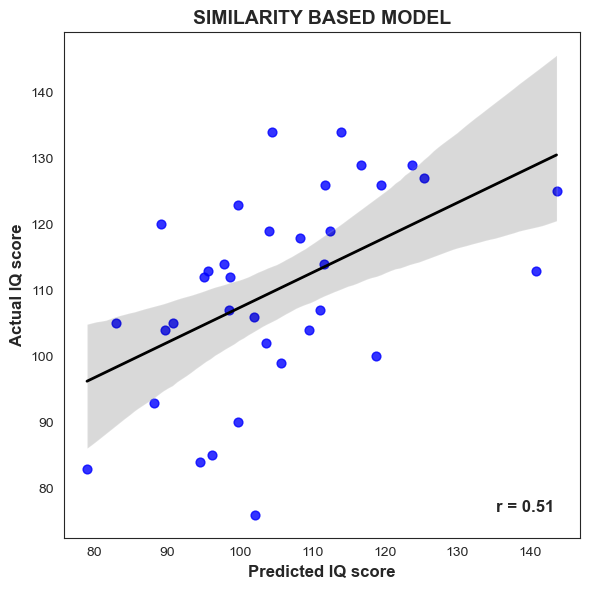

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Ensure numpy arrays
test_pred = np.array(p)
y_test_h = np.array(ytest)

# -------------------------------------------------
# PEARSON CORRELATION
# -------------------------------------------------
r, _ = pearsonr(test_pred, y_test_h)

# -------------------------------------------------
# STYLE
# -------------------------------------------------
sns.set_style("white")
plt.figure(figsize=(6, 6))

# Regression plot with confidence interval
sns.regplot(
    x=test_pred,
    y=y_test_h,
    scatter_kws={'color': 'blue', 'alpha': 0.8, 's': 40},
    line_kws={'color': 'black', 'linewidth': 2},
    ci=95
)

# Labels
plt.xlabel("Predicted IQ score", fontsize=12, weight='bold')
plt.ylabel("Actual IQ score", fontsize=12, weight='bold')
plt.title("SIMILARITY BASED MODEL", fontsize=14, weight='bold')

# Display correlation inside plot
plt.text(
    0.95, 0.05,
    f"r = {r:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12, weight='bold',
    horizontalalignment='right'
)

# Clean look
plt.grid(False)
plt.tight_layout()
plt.savefig(
    "similarity_model_plot.png",
    dpi=600,                 # 300 for normal HD, 600 for journal quality
    bbox_inches="tight",
    format="png"
)
plt.show()